In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up for better plots/
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 1. Loading Data

### 1.1 Loading the main datasets

In [13]:
JobCards_filtered = pd.read_csv('/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/3. Processed/JobCards_filtered.csv')
Workers_filtered = pd.read_csv('/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/3. Processed/Workers_filtered.csv')
Census_Panchayat_inequity = pd.read_csv('/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/3. Processed/Census_Panchayat_inequity.csv')

print("JobCards_filtered:")
display(JobCards_filtered.head())

print("\nWorkers_filtered:")
display(Workers_filtered.head())   

print("\nCensus_Panchayat_inequity:")
display(Census_Panchayat_inequity.head())

JobCards_filtered:


,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,cumul_hh_jobcards_tot
0,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Campbell Bay,376.0,800.0,4.0,2.0,369.0,375.0
1,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Govindnagar,429.0,813.0,0.0,0.0,429.0,429.0
2,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Laxmi Nagar,460.0,819.0,0.0,0.0,460.0,460.0
3,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,632.0,0.0,309.0,0.0,309.0
4,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Kamorta Tc,612.0,1344.0,0.0,491.0,121.0,612.0



Workers_filtered:


,year,state_name,district_name,block_name,gp_name,applied_jobcards,issued_jobcards,registered_workers_scs,registered_workers_sts,registered_workers_others,total_registered_workers,active_jobcards,active_workers_scs,active_workers_sts,active_workers_others,total_active_workers
0,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Campbell Bay,376.0,375.0,0.0,0.0,718.0,718.0,137.0,0.0,0.0,10.0,10.0
1,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Govindnagar,429.0,429.0,0.0,0.0,790.0,790.0,258.0,0.0,0.0,51.0,51.0
2,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Laxmi Nagar,460.0,460.0,0.0,0.0,922.0,922.0,237.0,0.0,0.0,24.0,24.0
3,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,309.0,0.0,646.0,2.0,648.0,150.0,0.0,63.0,2.0,65.0
4,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Kamorta Tc,612.0,612.0,0.0,1255.0,191.0,1446.0,388.0,0.0,443.0,15.0,458.0



Census_Panchayat_inequity:


,Unnamed: 0,mis_index,equity_score1,equity_score2,equity_score3,equity_score4,category,equity_score5,inequity_score,group,state_name,district_name,subdistrict_name,tot_pop_persons,SC_pop_persons,ST_pop_persons
0,0,166463,0.018656,0.004735,0.094903,0.189998,3,0.084442,1.763303,SC,andhra pradesh,vizianagaram,bondapalle,50531.0,5712.0,1445.0
1,1,166475,0.597425,-0.161602,0.302553,0.005162,2,0.015320,1.619678,SC,andhra pradesh,vizianagaram,denkada,46486.0,4805.0,92.0
2,2,166478,0.103851,NaN,0.120494,0.120689,3,0.022218,1.982577,SC,andhra pradesh,vizianagaram,denkada,46486.0,4805.0,92.0
3,3,166479,0.469600,-0.351881,0.468233,0.243940,3,0.064675,1.531420,SC,andhra pradesh,vizianagaram,denkada,46486.0,4805.0,92.0
4,4,166533,0.278150,0.551750,0.388139,0.166026,2,0.053694,1.289105,SC,andhra pradesh,vizianagaram,parvathipuram,58575.0,6675.0,8895.0


### 1.2 Loading the mapper

In [14]:
PC_MIS_mapping = pd.read_csv("/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/2. Interim/Cleaned_PC_MIS_mapping.csv")
print("\nPC_MIS_mapping:")
display(PC_MIS_mapping.head())


PC_MIS_mapping:


,Panchayat_ID,Gram_panchayat_name,Subdistrict census code,Subdistrict name,District census code,District name,State census code,State name,mis_index
0,221810,pitchikalapadu,4730,yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
1,221811,kannaigudem,4730,yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
2,221812,laxmipuram,4730,yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
3,221813,ramagopalapuram,4730,yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
4,221814,nallakunta,4730,yetapaka,541,visakhapatnam,28,andhra pradesh,NaN


### 1.3 Combining JobCards and Workers datasets

In [17]:
gp_key = ['year', 'state_name', 'district_name', 'block_name', 'gp_name']

IDP_NREGA = JobCards_filtered.merge(Workers_filtered, on=gp_key, how='outer')

print(f'JobCards_filtered rows:  {len(JobCards_filtered):,}')
print(f'Workers_filtered rows:   {len(Workers_filtered):,}')
print(f'Combined IDP_NREGA rows:     {len(IDP_NREGA):,}')
IDP_NREGA.head()

JobCards_filtered rows:  2,598,530
Workers_filtered rows:   2,460,169
Combined IDP_NREGA rows:     2,760,830


,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,...,issued_jobcards,registered_workers_scs,registered_workers_sts,registered_workers_others,total_registered_workers,active_jobcards,active_workers_scs,active_workers_sts,active_workers_others,total_active_workers
0,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Campbell Bay,376.0,800.0,4.0,2.0,369.0,...,375.0,0.0,0.0,718.0,718.0,137.0,0.0,0.0,10.0,10.0
1,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Govindnagar,429.0,813.0,0.0,0.0,429.0,...,429.0,0.0,0.0,790.0,790.0,258.0,0.0,0.0,51.0,51.0
2,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Laxmi Nagar,460.0,819.0,0.0,0.0,460.0,...,460.0,0.0,0.0,922.0,922.0,237.0,0.0,0.0,24.0,24.0
3,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,632.0,0.0,309.0,0.0,...,309.0,0.0,646.0,2.0,648.0,150.0,0.0,63.0,2.0,65.0
4,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Kamorta Tc,612.0,1344.0,0.0,491.0,121.0,...,612.0,0.0,1255.0,191.0,1446.0,388.0,0.0,443.0,15.0,458.0


## 2. Programme Ratios

For each indicator, the programme ratio is the share of total recipients belonging to SC or ST households:
- **SC ratio** = SC count / total count
- **ST ratio** = ST count / total count
- **SC+ST ratio** = (SC + ST) count / total count

Computed for three indicators: job cards issued (`cumul_hh_jobcards`), registered workers, and active workers.

In [18]:
# Job cards
IDP_NREGA['jobcards_ratio_sc']   = IDP_NREGA['cumul_hh_jobcards_sc']  / IDP_NREGA['cumul_hh_jobcards_tot']
IDP_NREGA['jobcards_ratio_st']   = IDP_NREGA['cumul_hh_jobcards_sts'] / IDP_NREGA['cumul_hh_jobcards_tot']
IDP_NREGA['jobcards_ratio_scst'] = (IDP_NREGA['cumul_hh_jobcards_sc'] + IDP_NREGA['cumul_hh_jobcards_sts']) / IDP_NREGA['cumul_hh_jobcards_tot']

# Registered workers
IDP_NREGA['reg_workers_ratio_sc']   = IDP_NREGA['registered_workers_scs'] / IDP_NREGA['total_registered_workers']
IDP_NREGA['reg_workers_ratio_st']   = IDP_NREGA['registered_workers_sts'] / IDP_NREGA['total_registered_workers']
IDP_NREGA['reg_workers_ratio_scst'] = (IDP_NREGA['registered_workers_scs'] + IDP_NREGA['registered_workers_sts']) / IDP_NREGA['total_registered_workers']

# Active workers
IDP_NREGA['active_workers_ratio_sc']   = IDP_NREGA['active_workers_scs'] / IDP_NREGA['total_active_workers']
IDP_NREGA['active_workers_ratio_st']   = IDP_NREGA['active_workers_sts'] / IDP_NREGA['total_active_workers']
IDP_NREGA['active_workers_ratio_scst'] = (IDP_NREGA['active_workers_scs'] + IDP_NREGA['active_workers_sts']) / IDP_NREGA['total_active_workers']

ratio_cols = [c for c in IDP_NREGA.columns if 'ratio' in c]
IDP_NREGA[ratio_cols].describe().round(3)

,jobcards_ratio_sc,jobcards_ratio_st,jobcards_ratio_scst,reg_workers_ratio_sc,reg_workers_ratio_st,reg_workers_ratio_scst,active_workers_ratio_sc,active_workers_ratio_st,active_workers_ratio_scst
count,2598530.000,2598530.000,2598530.000,2460169.000,2460169.000,2460169.000,2460169.000,2460169.000,2460169.000
mean,0.221,0.156,0.377,0.217,0.143,0.360,0.222,0.143,0.364
std,0.223,0.297,0.297,0.214,0.281,0.286,0.227,0.283,0.295
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.039,0.000,0.138,0.046,0.000,0.134,0.038,0.000,0.125
50%,0.160,0.003,0.305,0.159,0.004,0.289,0.155,0.002,0.293
75%,0.329,0.130,0.560,0.320,0.109,0.526,0.331,0.105,0.547
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 3. Merging IDP_NREGA with Census & Inequity Data

The goal is to attach Mittal inequity scores and 2001 Census population data to each GP in `IDP_NREGA`. The link chain is:
- **IDP_NREGA** (GP names from the IDP portal) → **PC_MIS_mapping** (Census GP names + `mis_index`) → **Census_Panchayat_inequity** (inequity scores + census data keyed by `mis_index`)

The join is done on `(state_name, district_name, gp_name)`. `block_name` is excluded because IDP blocks and Census subdistricts don't reliably correspond to the same admin unit.

**Known coverage limits:** PC_MIS_mapping only covers ~14 states (Mittal paper sample) and uses Census 2001 district boundaries — many post-2001 district splits in states like Chhattisgarh and Bihar are absent. Even within covered districts, GP naming conventions differ between the IDP portal and Census. Expect a match rate of ~21%.

### 3.1 Normalising name columns

GP and district names use different separator conventions across the two sources — the IDP portal uses parentheses (`rajpur (pakhanva)`) while PC_MIS_mapping uses underscores (`rajpur _pakhanva`). Replacing `(`, `)`, `_`, `.`, `-` with spaces and collapsing whitespace resolves these and recovers additional matches.

In [20]:
import re

def normalise(s):
    if pd.isna(s): return s
    s = re.sub(r'[()_.\-]', ' ', str(s))
    return re.sub(r'\s+', ' ', s).strip()

norm_cols = ['state_name', 'district_name', 'gp_name']
for col in norm_cols:
    IDP_NREGA[col + '_n'] = IDP_NREGA[col].str.strip().str.lower().apply(normalise)

PC_MIS_norm = PC_MIS_mapping.rename(columns={
    'State name': 'state_name',
    'District name': 'district_name',
    'Gram_panchayat_name': 'gp_name'
}).copy()
for col in norm_cols:
    PC_MIS_norm[col + '_n'] = PC_MIS_norm[col].str.strip().str.lower().apply(normalise)

print('Normalisation complete.')

Normalisation complete.


### 3.2 Building the GP → `mis_index` lookup

PC_MIS_mapping has one row per Census panchayat. We keep only rows with a non-null `mis_index` (the ~53% with Mittal coverage) and deduplicate on the normalised `(state, district, gp)` triplet. Where two Census GPs share the same normalised name in the same district, we keep the first — these ambiguous cases are rare (~1% of lookup entries) and unavoidable without a formal crosswalk.

In [21]:
norm_key = ['state_name_n', 'district_name_n', 'gp_name_n']

gp_mis_lookup = (
    PC_MIS_norm
    .dropna(subset=['mis_index'])
    .drop_duplicates(subset=norm_key)
    [norm_key + ['mis_index']]
)

print(f'Lookup entries: {len(gp_mis_lookup):,}')

Lookup entries: 105,066


### 3.3 Joining IDP_NREGA to the lookup

Left join on the normalised triplet — every IDP GP-year row is kept; those without a Census match receive a null `mis_index` and will have NaN inequity columns in the final dataset.

In [22]:
IDP_NREGA_linked = IDP_NREGA.merge(gp_mis_lookup, on=norm_key, how='left')

matched = IDP_NREGA_linked['mis_index'].notna().sum()
print(f'GP-year rows matched to mis_index: {matched:,} / {len(IDP_NREGA_linked):,} '
      f'({100*matched/len(IDP_NREGA_linked):.1f}%)')

GP-year rows matched to mis_index: 614,486 / 2,760,830 (22.3%)


### 3.4 Attaching Census & Inequity data

Join on `mis_index` to bring in the Mittal equity/inequity scores and 2001 Census subdistrict population counts. `Census_Panchayat_inequity` has one row per panchayat (SC and ST scores are in the same row under the `group` column), so this is a one-to-one join on `mis_index`.

In [23]:
IDP_NREGA_inequity = IDP_NREGA_linked.merge(
    Census_Panchayat_inequity.drop(columns='Unnamed: 0', errors='ignore'),
    on='mis_index', how='left'
)

# Drop the normalised helper columns — no longer needed
IDP_NREGA_inequity = IDP_NREGA_inequity.drop(columns=[c for c in IDP_NREGA_inequity.columns if c.endswith('_n')])

n_with_inequity = IDP_NREGA_inequity['inequity_score'].notna().sum()
print(f'Rows with inequity data: {n_with_inequity:,} / {len(IDP_NREGA_inequity):,} '
      f'({100*n_with_inequity/len(IDP_NREGA_inequity):.1f}%)')
IDP_NREGA_inequity.head()

Rows with inequity data: 338,178 / 2,760,830 (12.2%)


,year,state_name_x,district_name_x,block_name,gp_name,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,...,category,equity_score5,inequity_score,group,state_name_y,district_name_y,subdistrict_name,tot_pop_persons,SC_pop_persons,ST_pop_persons
0,2014-2015,andaman and nicobar,nicobars,campbell bay,campbell bay,376.0,800.0,4.0,2.0,369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-2015,andaman and nicobar,nicobars,campbell bay,govindnagar,429.0,813.0,0.0,0.0,429.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-2015,andaman and nicobar,nicobars,campbell bay,laxmi nagar,460.0,819.0,0.0,0.0,460.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-2015,andaman and nicobar,nicobars,nancowry,chowra tc,309.0,632.0,0.0,309.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-2015,andaman and nicobar,nicobars,nancowry,kamorta tc,612.0,1344.0,0.0,491.0,121.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.5 Cleaning up duplicate columns

After the two joins, `state_name` and `district_name` appear twice — `_x` from `IDP_NREGA` (the IDP portal names) and `_y` from `Census_Panchayat_inequity` (Census names). We keep the IDP versions as the primary reference and drop the Census duplicates.

In [25]:
IDP_NREGA_inequity = IDP_NREGA_inequity.rename(columns={
    'state_name_x': 'state_name',
    'district_name_x': 'district_name'
}).drop(columns=['state_name_y', 'district_name_y'])

print(IDP_NREGA_inequity.shape)
IDP_NREGA_inequity.head()

(2760830, 44)


,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,...,equity_score3,equity_score4,category,equity_score5,inequity_score,group,subdistrict_name,tot_pop_persons,SC_pop_persons,ST_pop_persons
0,2014-2015,andaman and nicobar,nicobars,campbell bay,campbell bay,376.0,800.0,4.0,2.0,369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-2015,andaman and nicobar,nicobars,campbell bay,govindnagar,429.0,813.0,0.0,0.0,429.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-2015,andaman and nicobar,nicobars,campbell bay,laxmi nagar,460.0,819.0,0.0,0.0,460.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-2015,andaman and nicobar,nicobars,nancowry,chowra tc,309.0,632.0,0.0,309.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-2015,andaman and nicobar,nicobars,nancowry,kamorta tc,612.0,1344.0,0.0,491.0,121.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.6 Targeting ratios

A **targeting ratio** measures how over- or under-represented SC/ST households are among programme recipients, relative to their population share:

$$\text{targeting ratio} = \frac{\text{SC/ST share of recipients}}{\text{SC/ST share of population}}$$

A value > 1 means SC/ST households receive a higher share of benefits than their population share (pro-poor targeting). A value < 1 means they are under-served.

Computed for three indicators — job cards, registered workers, active workers — and three groups: SC, ST, SC+ST.

In [27]:
# Population shares (from 2001 Census, subdistrict level)
sc_pop_share   = IDP_NREGA_inequity['SC_pop_persons'] / IDP_NREGA_inequity['tot_pop_persons']
st_pop_share   = IDP_NREGA_inequity['ST_pop_persons'] / IDP_NREGA_inequity['tot_pop_persons']
scst_pop_share = (IDP_NREGA_inequity['SC_pop_persons'] + IDP_NREGA_inequity['ST_pop_persons']) / IDP_NREGA_inequity['tot_pop_persons']

# Job cards targeting ratios
IDP_NREGA_inequity['jobcards_targeting_sc']   = IDP_NREGA_inequity['jobcards_ratio_sc']   / sc_pop_share
IDP_NREGA_inequity['jobcards_targeting_st']   = IDP_NREGA_inequity['jobcards_ratio_st']   / st_pop_share
IDP_NREGA_inequity['jobcards_targeting_scst'] = IDP_NREGA_inequity['jobcards_ratio_scst'] / scst_pop_share

# Registered workers targeting ratios
IDP_NREGA_inequity['reg_workers_targeting_sc']   = IDP_NREGA_inequity['reg_workers_ratio_sc']   / sc_pop_share
IDP_NREGA_inequity['reg_workers_targeting_st']   = IDP_NREGA_inequity['reg_workers_ratio_st']   / st_pop_share
IDP_NREGA_inequity['reg_workers_targeting_scst'] = IDP_NREGA_inequity['reg_workers_ratio_scst'] / scst_pop_share

# Active workers targeting ratios
IDP_NREGA_inequity['active_workers_targeting_sc']   = IDP_NREGA_inequity['active_workers_ratio_sc']   / sc_pop_share
IDP_NREGA_inequity['active_workers_targeting_st']   = IDP_NREGA_inequity['active_workers_ratio_st']   / st_pop_share
IDP_NREGA_inequity['active_workers_targeting_scst'] = IDP_NREGA_inequity['active_workers_ratio_scst'] / scst_pop_share

targeting_cols = [c for c in IDP_NREGA_inequity.columns if 'targeting' in c]
IDP_NREGA_inequity[targeting_cols].describe().round(3)

/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,jobcards_targeting_sc,jobcards_targeting_st,jobcards_targeting_scst,reg_workers_targeting_sc,reg_workers_targeting_st,reg_workers_targeting_scst,active_workers_targeting_sc,active_workers_targeting_st,active_workers_targeting_scst
count,274236.000,243561.000,274236.000,265104.000,235256.000,265104.000,265104.000,234706.000,265104.000
mean,1.517,inf,1.405,1.455,inf,1.360,1.467,inf,1.362
std,1.590,NaN,1.008,1.457,NaN,0.955,1.590,NaN,1.061
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.683,0.051,0.846,0.680,0.081,0.819,0.604,0.000,0.764
50%,1.262,0.735,1.229,1.214,0.741,1.192,1.172,0.632,1.168
75%,1.985,1.548,1.805,1.914,1.525,1.748,1.944,1.386,1.752
max,72.534,inf,59.319,65.465,inf,54.522,60.045,inf,52.359


### 3.7 Analysis dataset

`IDP_NREGA_analysis` keeps only the overall `inequity_score` and drops the five component equity scores (`equity_score1`–`5`), which are intermediate constructs not needed for the main analysis.

In [30]:
drop_cols = ['equity_score1', 'equity_score2', 'equity_score3', 'equity_score4', 'equity_score5']

IDP_NREGA_analysis = IDP_NREGA_inequity.drop(columns=drop_cols)

print(f'Columns: {list(IDP_NREGA_analysis.columns)}')
print(f'Shape: {IDP_NREGA_analysis.shape}')

Columns: ['year', 'state_name', 'district_name', 'block_name', 'gp_name', 'reg_hh', 'reg_pers', 'cumul_hh_jobcards_sc', 'cumul_hh_jobcards_sts', 'cumul_hh_jobcards_others', 'cumul_hh_jobcards_tot', 'applied_jobcards', 'issued_jobcards', 'registered_workers_scs', 'registered_workers_sts', 'registered_workers_others', 'total_registered_workers', 'active_jobcards', 'active_workers_scs', 'active_workers_sts', 'active_workers_others', 'total_active_workers', 'jobcards_ratio_sc', 'jobcards_ratio_st', 'jobcards_ratio_scst', 'reg_workers_ratio_sc', 'reg_workers_ratio_st', 'reg_workers_ratio_scst', 'active_workers_ratio_sc', 'active_workers_ratio_st', 'active_workers_ratio_scst', 'mis_index', 'category', 'inequity_score', 'group', 'subdistrict_name', 'tot_pop_persons', 'SC_pop_persons', 'ST_pop_persons', 'jobcards_targeting_sc', 'jobcards_targeting_st', 'jobcards_targeting_scst', 'reg_workers_targeting_sc', 'reg_workers_targeting_st', 'reg_workers_targeting_scst', 'active_workers_targeting_sc',

## 4. Scatter Plots: Targeting vs Inequity

Each scatter plot shows one targeting ratio (x-axis) against `inequity_score` (y-axis), filtered to rows with non-null values for both variables. A vertical dashed line at x = 1 marks neutral targeting (recipients match population share).

- **Row 1:** SC+ST targeting ratios — all matched rows
- **Row 2:** SC targeting ratios — rows where `group == 'SC'`
- **Row 3:** ST targeting ratios — rows where `group == 'ST'`

Points are sampled (up to 5,000 per panel) and plotted with transparency to reduce overplotting.

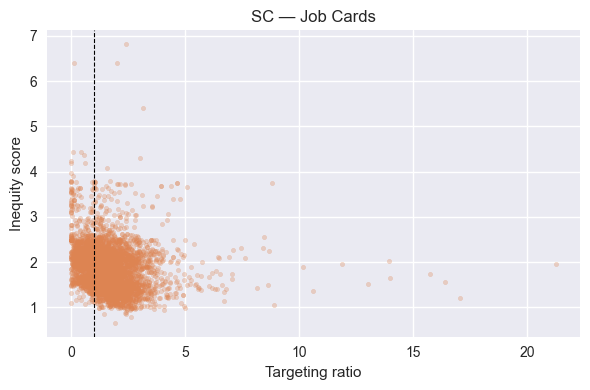

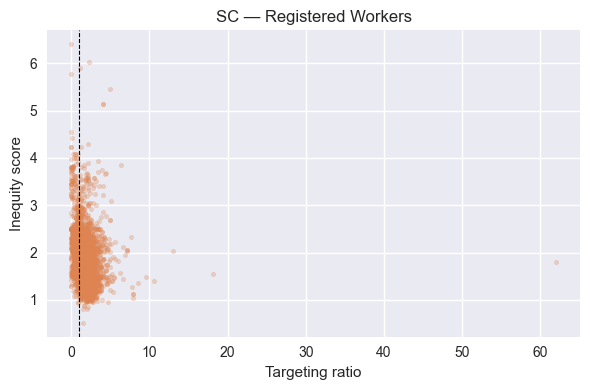

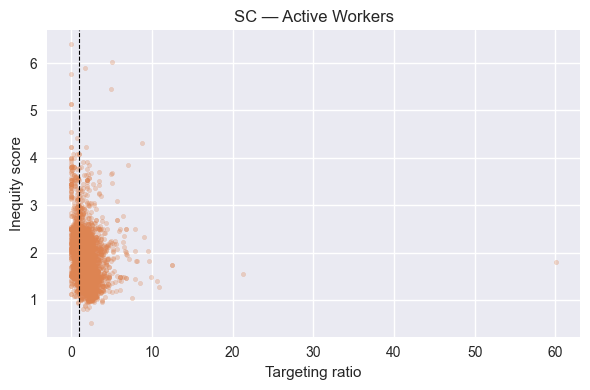

In [38]:
# SC targeting ratios
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_analysis[IDP_NREGA_analysis['group'] == 'SC']

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['jobcards_targeting_sc', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter((df['jobcards_targeting_sc']), df['inequity_score'], alpha=ALPHA, s=10, color='#DD8452')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('SC — Job Cards', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['reg_workers_targeting_sc', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter((df['reg_workers_targeting_sc']), df['inequity_score'], alpha=ALPHA, s=10, color='#DD8452')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('SC — Registered Workers', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['active_workers_targeting_sc', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter((df['active_workers_targeting_sc']), df['inequity_score'], alpha=ALPHA, s=10, color='#DD8452')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('SC — Active Workers', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()



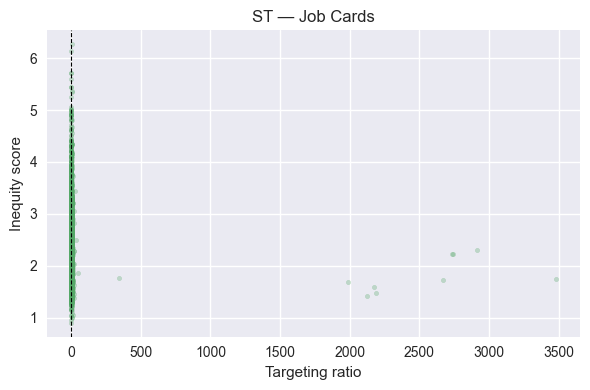

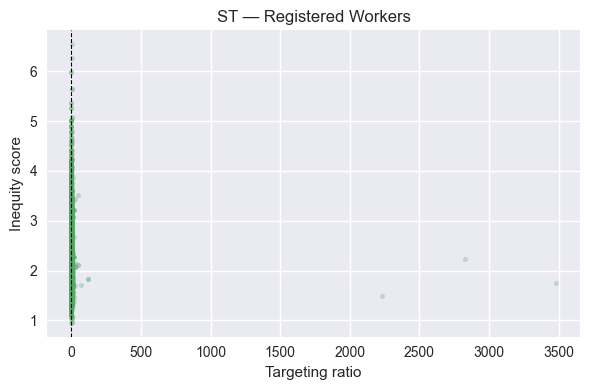

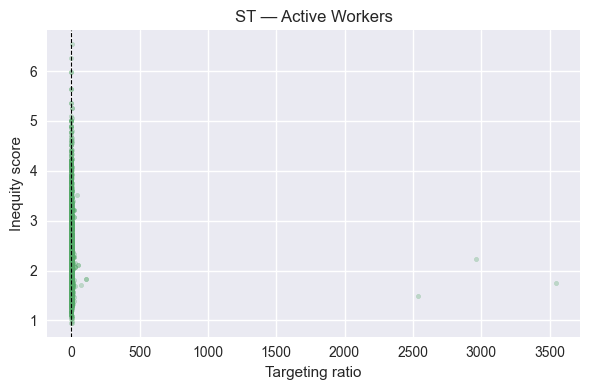

In [40]:
# ST targeting ratios
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_analysis[IDP_NREGA_analysis['group'] == 'ST']

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['jobcards_targeting_st', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter(df['jobcards_targeting_st'], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('ST — Job Cards', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['reg_workers_targeting_st', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter(df['reg_workers_targeting_st'], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('ST — Registered Workers', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df = df_base.dropna(subset=['active_workers_targeting_st', 'inequity_score'])
if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
ax.scatter(df['active_workers_targeting_st'], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_title('ST — Active Workers', fontsize=12)
ax.set_xlabel('Targeting ratio', fontsize=11)
ax.set_ylabel('Inequity score', fontsize=11)
plt.tight_layout()
plt.show()



## 5. Outlier-Robust Scatter Plots

The raw targeting ratios have a long right tail — GPs where the population share of SC/ST is near zero produce extremely large ratios that compress the bulk of the data into a narrow band. Two approaches are used side by side:

- **Winsorized (top row per group):** targeting ratios clipped at the 1st and 99th percentile. Preserves the original scale and all data points; outliers are brought in to the clip boundary.
- **Log-transformed (bottom row per group):** `log(targeting ratio)` plotted on the x-axis. Maps neutral targeting (ratio = 1) to 0, over-targeting to positive, under-targeting to negative. Rows with a targeting ratio of 0 are excluded (log undefined). The dashed line marks x = 0 (neutral).

In [41]:
targeting_cols = [
    'jobcards_targeting_scst',
    'reg_workers_targeting_scst',
    'active_workers_targeting_scst',
    'jobcards_targeting_sc',
    'reg_workers_targeting_sc',
    'active_workers_targeting_sc',
    'jobcards_targeting_st',
    'reg_workers_targeting_st',
    'active_workers_targeting_st',
]

# Winsorised copies
for col in targeting_cols:
    lo = IDP_NREGA_analysis[col].quantile(0.01)
    hi = IDP_NREGA_analysis[col].quantile(0.99)
    IDP_NREGA_analysis[col + '_w'] = IDP_NREGA_analysis[col].clip(lo, hi)

# Log-transformed copies (excludes zeros)
for col in targeting_cols:
    IDP_NREGA_analysis[col + '_log'] = np.where(
        IDP_NREGA_analysis[col] > 0,
        np.log(IDP_NREGA_analysis[col]),
        np.nan
    )

print('Winsorised and log-transformed columns added.')

/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/vidhi/Library/Python/3.12/lib/python/s

Winsorised and log-transformed columns added.


### 5.1 SC+ST vs inequity index

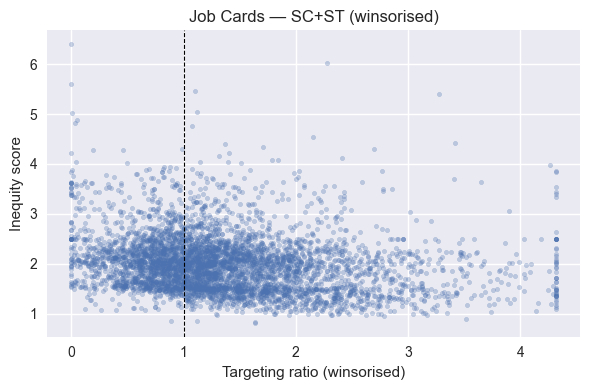

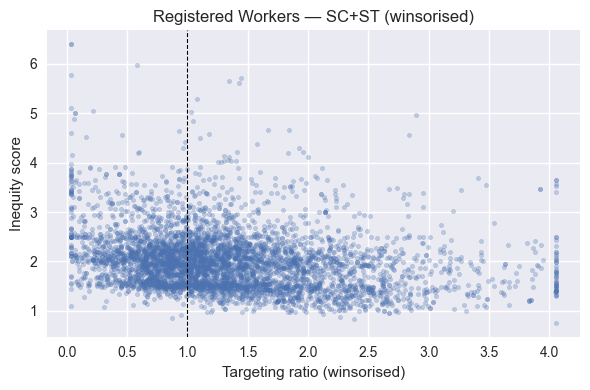

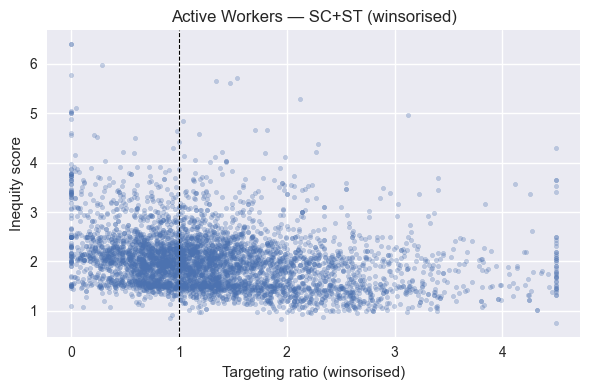

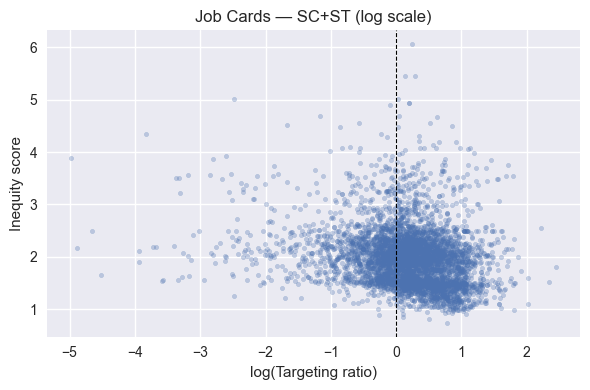

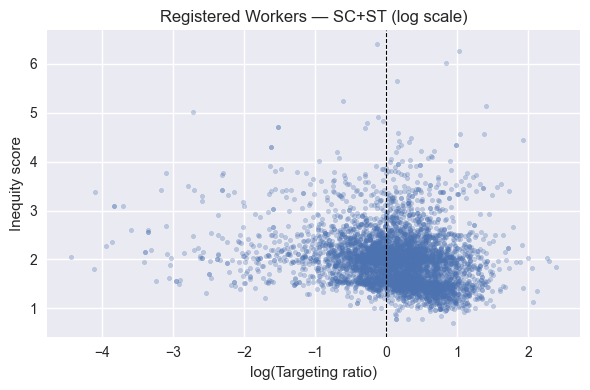

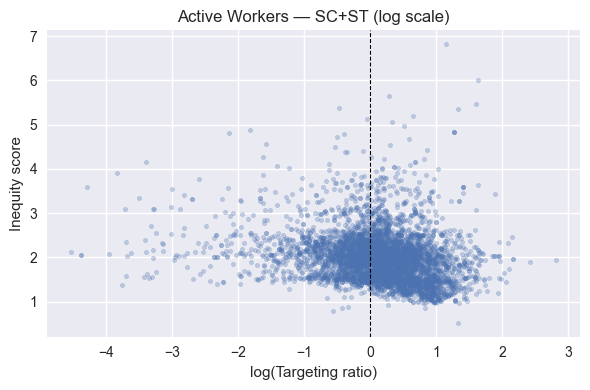

In [43]:
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_analysis.copy()

# --- Winsorised ---
for x_col, title in zip(['jobcards_targeting_scst_w', 'reg_workers_targeting_scst_w', 'active_workers_targeting_scst_w'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#4C72B0')
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — SC+ST (winsorised)', fontsize=12)
    ax.set_xlabel('Targeting ratio (winsorised)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()

# --- Log-transformed ---
for x_col, title in zip(['jobcards_targeting_scst_log', 'reg_workers_targeting_scst_log', 'active_workers_targeting_scst_log'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#4C72B0')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — SC+ST (log scale)', fontsize=12)
    ax.set_xlabel('log(Targeting ratio)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()


### 5.2 SC vs inequity index

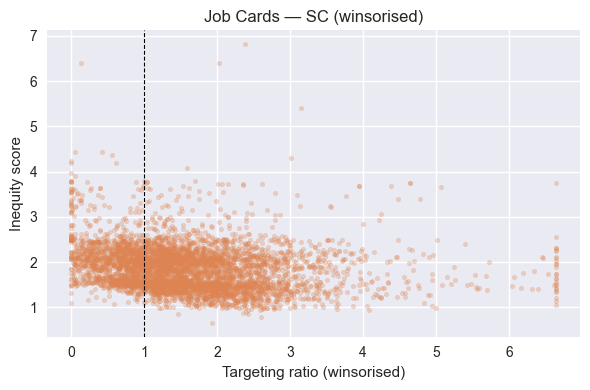

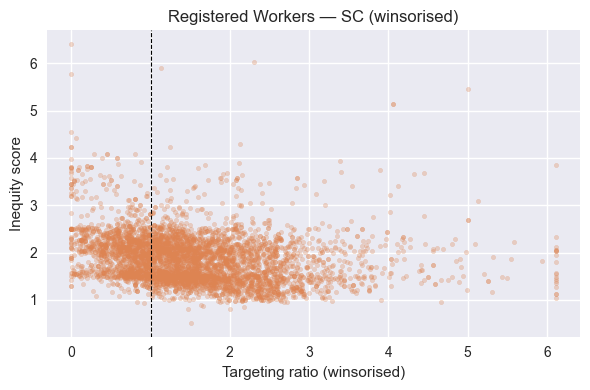

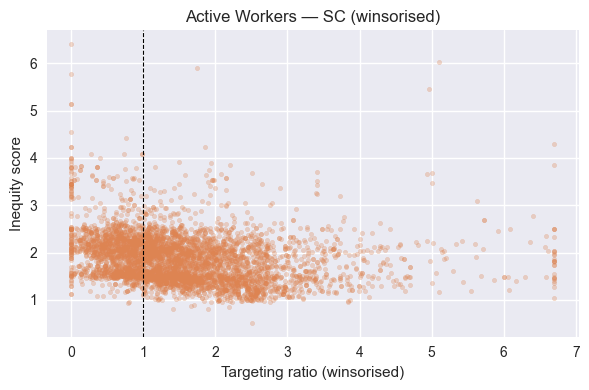

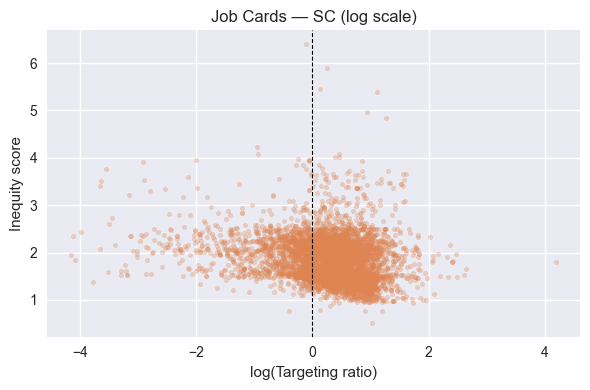

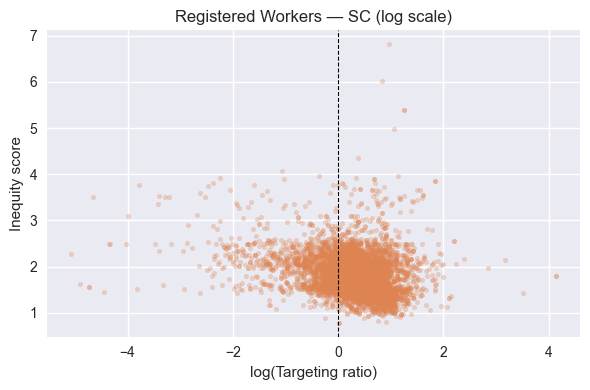

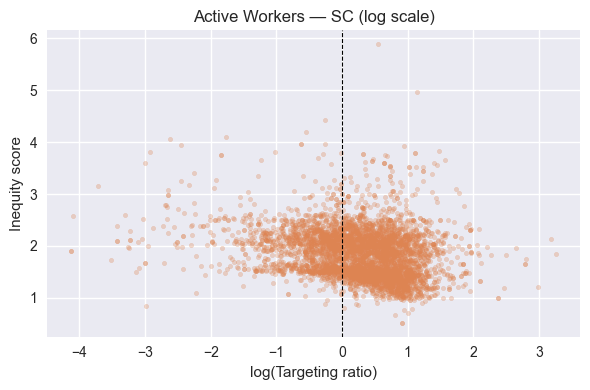

In [44]:
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_analysis[IDP_NREGA_analysis['group'] == 'SC']

# --- Winsorised ---
for x_col, title in zip(['jobcards_targeting_sc_w', 'reg_workers_targeting_sc_w', 'active_workers_targeting_sc_w'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#DD8452')
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — SC (winsorised)', fontsize=12)
    ax.set_xlabel('Targeting ratio (winsorised)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()

# --- Log-transformed ---
for x_col, title in zip(['jobcards_targeting_sc_log', 'reg_workers_targeting_sc_log', 'active_workers_targeting_sc_log'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#DD8452')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — SC (log scale)', fontsize=12)
    ax.set_xlabel('log(Targeting ratio)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()


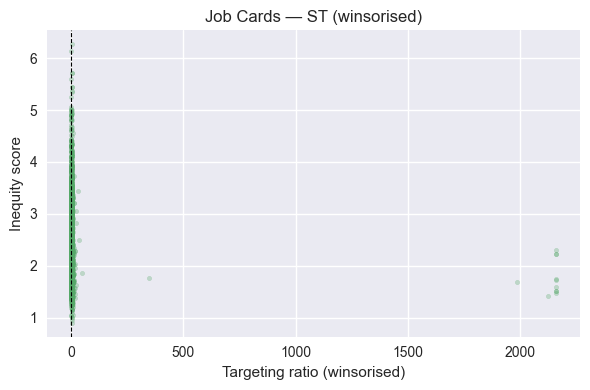

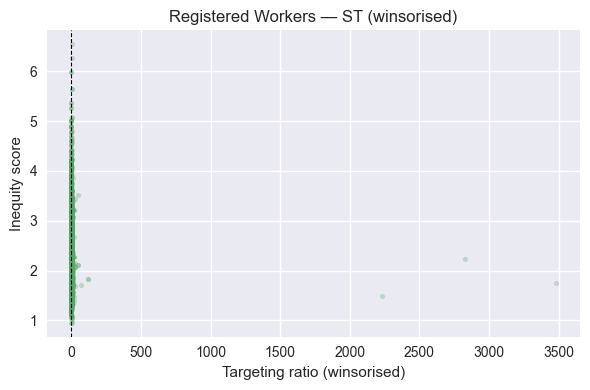

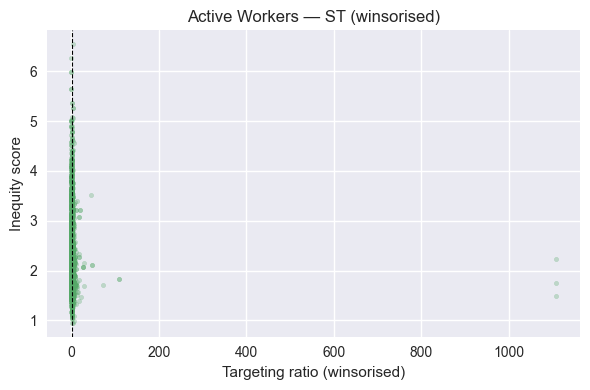

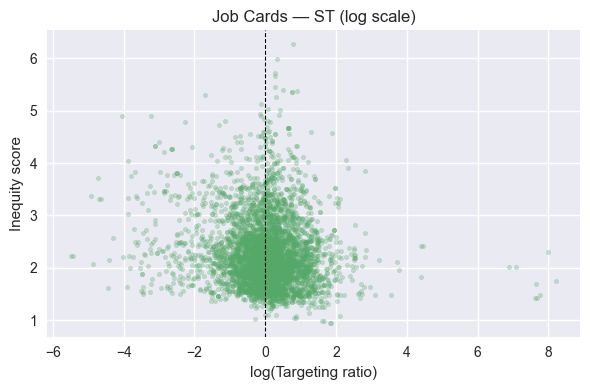

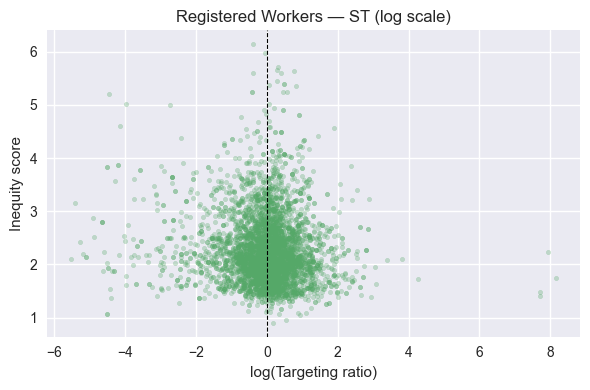

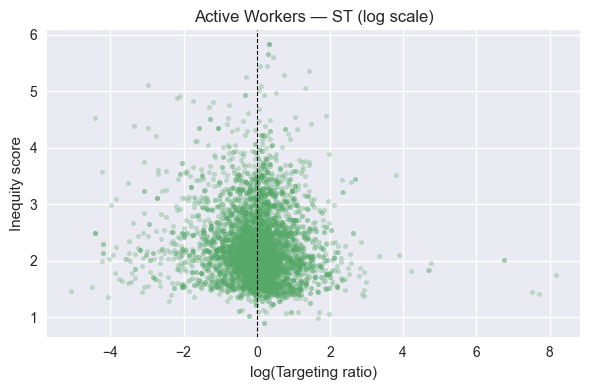

In [45]:
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_analysis[IDP_NREGA_analysis['group'] == 'ST']

# --- Winsorised ---
for x_col, title in zip(['jobcards_targeting_st_w', 'reg_workers_targeting_st_w', 'active_workers_targeting_st_w'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — ST (winsorised)', fontsize=12)
    ax.set_xlabel('Targeting ratio (winsorised)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()

# --- Log-transformed ---
for x_col, title in zip(['jobcards_targeting_st_log', 'reg_workers_targeting_st_log', 'active_workers_targeting_st_log'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — ST (log scale)', fontsize=12)
    ax.set_xlabel('log(Targeting ratio)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()


Looking at 1 to 90th percentile for ST since the patterns are still not showing up.

In [50]:
targeting_cols_st = [
    'jobcards_targeting_st',
    'reg_workers_targeting_st',
    'active_workers_targeting_st',
]
IDP_NREGA_temp = IDP_NREGA_analysis.copy()
# Winsorised copies
for col in targeting_cols_st:
    lo = IDP_NREGA_analysis[col].quantile(0.01)
    hi = IDP_NREGA_analysis[col].quantile(0.90)
    IDP_NREGA_temp[col + '_w'] = IDP_NREGA_temp[col].clip(lo, hi)

# Log-transformed copies (excludes zeros)
for col in targeting_cols_st:
    IDP_NREGA_temp[col + '_log'] = np.where(
        IDP_NREGA_temp[col] > 0,
        np.log(IDP_NREGA_temp[col]),
        np.nan
    )

print('Winsorised and log-transformed columns added.')

Winsorised and log-transformed columns added.


/Users/vidhi/Library/Python/3.12/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


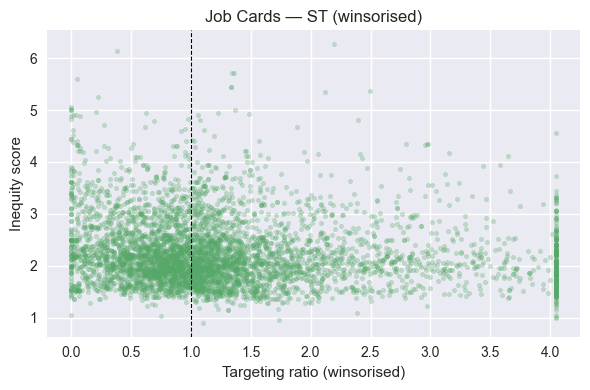

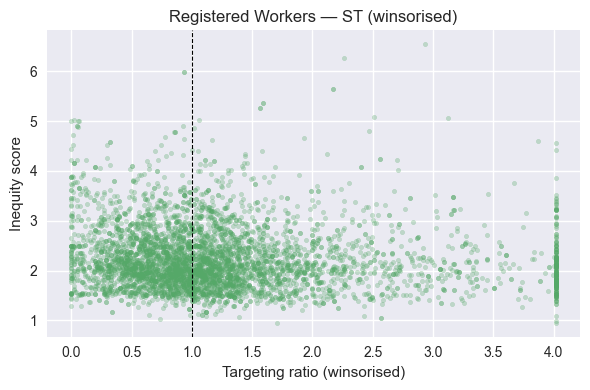

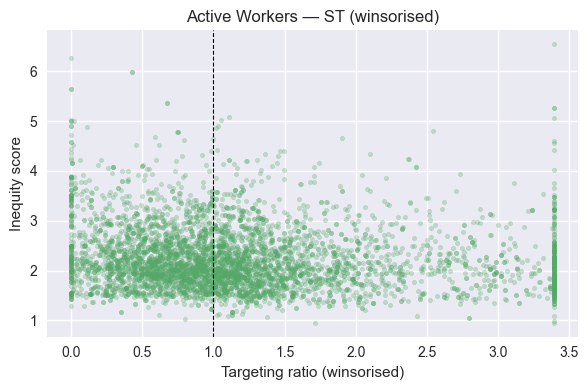

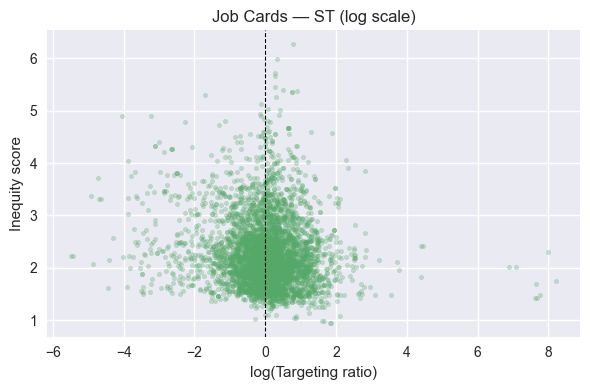

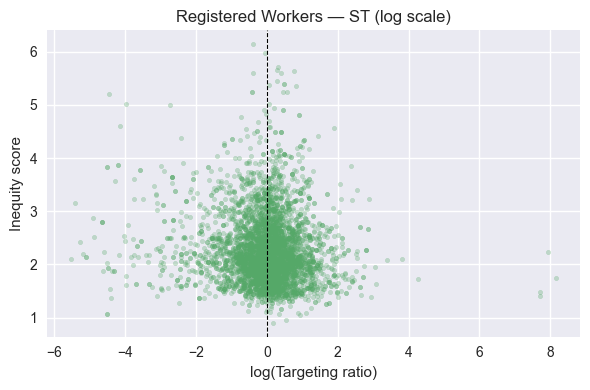

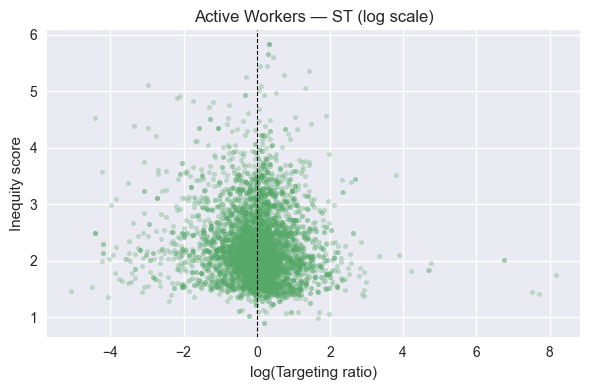

In [51]:
SAMPLE = 5000
ALPHA  = 0.3

df_base = IDP_NREGA_temp[IDP_NREGA_temp['group'] == 'ST']

# --- Winsorised ---
for x_col, title in zip(['jobcards_targeting_st_w', 'reg_workers_targeting_st_w', 'active_workers_targeting_st_w'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — ST (winsorised)', fontsize=12)
    ax.set_xlabel('Targeting ratio (winsorised)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()

# --- Log-transformed ---
for x_col, title in zip(['jobcards_targeting_st_log', 'reg_workers_targeting_st_log', 'active_workers_targeting_st_log'], ['Job Cards', 'Registered Workers', 'Active Workers']):
    df = df_base.dropna(subset=[x_col, 'inequity_score'])
    if len(df) > SAMPLE: df = df.sample(SAMPLE, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[x_col], df['inequity_score'], alpha=ALPHA, s=10, color='#55A868')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title} — ST (log scale)', fontsize=12)
    ax.set_xlabel('log(Targeting ratio)')
    ax.set_ylabel('Inequity score')
    plt.tight_layout(); plt.show()
